# Medical Device Failure Prediction — Model Training
### Cognizant AI Hackathon — Team Notebook

**Input**: `outputs/train.csv`, `outputs/test.csv`, `outputs/preprocessor.pkl`
**Target**: `failure` (binary) — see the EDA notebook for how this was derived and why USA-only
**Output**: `backend/app/ml/model.pkl`, `backend/app/ml/pipeline.pkl`, `outputs/metrics.json`

**This notebook is Approach B end to end**: `classification + description + manufacturer history
-> XGBoost -> P(failure) -> tuned threshold -> Failure YES/NO`. The threshold is tuned on
out-of-fold predictions (never on the test set), not assumed at an arbitrary value like 0.5 or 0.6.


In [1]:
import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score, cross_val_predict
from sklearn.metrics import (
    f1_score, roc_auc_score, precision_score, recall_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_curve
)
from xgboost import XGBClassifier

sns.set_style('whitegrid')
_nb = globals().get('__vsc_ipynb_file__') or globals().get('__file__')
_here = Path(_nb).parent.resolve() if _nb else Path.cwd()
OUT_DIR = (_here / 'outputs').resolve()
BACKEND_ML_DIR = (_here / '../backend/app/ml').resolve()
BACKEND_ML_DIR.mkdir(parents=True, exist_ok=True)

import sys
sys.path.insert(0, '.')
from model_classes import ThresholdedClassifier

FEATURE_COLS = ['classification', 'description', 'mfr_loo_event_count',
                'mfr_countries_all', 'mfr_devices_all', 'description_len',
                'classification_prior_count', 'event_year']


## 1. Load data

In [2]:
preprocessor = joblib.load(OUT_DIR / 'preprocessor.pkl')
train_df = pd.read_csv(OUT_DIR / 'train.csv')
test_df = pd.read_csv(OUT_DIR / 'test.csv')

for df in (train_df, test_df):
    df['description'] = df['description'].fillna('')
    df['classification'] = df['classification'].fillna('Unknown')

X_train = train_df[FEATURE_COLS]; y_train = train_df['failure']
X_test = test_df[FEATURE_COLS]; y_test = test_df['failure']

X_train_t = preprocessor.transform(X_train)
X_test_t = preprocessor.transform(X_test)
print(f'Train: {X_train_t.shape} (failure rate {y_train.mean():.3f})')
print(f'Test:  {X_test_t.shape} (failure rate {y_test.mean():.3f})')


Train: (26929, 821) (failure rate 0.456)
Test:  (6733, 821) (failure rate 0.456)


## 2. Model selection via 5-fold stratified CV (training set only)

In [3]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

candidates = {
    'Logistic Regression': LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42),
    'Random Forest': RandomForestClassifier(
        n_estimators=150, max_depth=18, min_samples_leaf=3,
        class_weight='balanced', random_state=42, n_jobs=-1
    ),
    'XGBoost': XGBClassifier(
        n_estimators=150, learning_rate=0.08, max_depth=6,
        subsample=0.8, colsample_bytree=0.8,
        eval_metric='logloss', random_state=42, n_jobs=-1
    ),
}

cv_results = {}
for name, model in candidates.items():
    scores = cross_val_score(model, X_train_t, y_train, cv=cv, scoring='roc_auc', n_jobs=1)
    cv_results[name] = scores
    print(f'{name:22s} CV ROC-AUC: {scores.mean():.4f}  (+/- {scores.std():.4f})')

best_name = max(cv_results, key=lambda k: cv_results[k].mean())
print(f'\nSelected model: {best_name}')


Logistic Regression    CV ROC-AUC: 0.7936  (+/- 0.0055)


Random Forest          CV ROC-AUC: 0.8419  (+/- 0.0083)


XGBoost                CV ROC-AUC: 0.8551  (+/- 0.0070)

Selected model: XGBoost


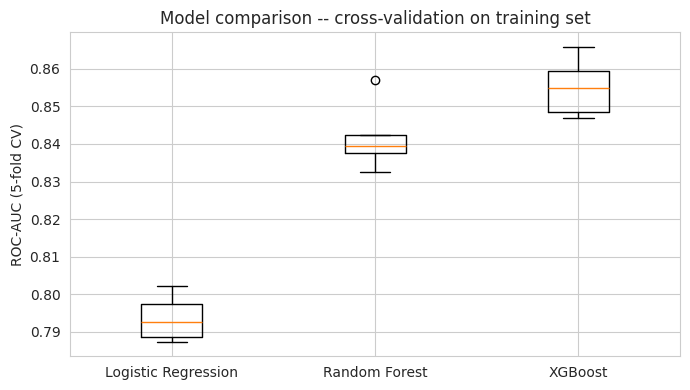

In [4]:
fig, ax = plt.subplots(figsize=(7,4))
ax.boxplot(cv_results.values(), tick_labels=list(cv_results.keys()))
ax.set_ylabel('ROC-AUC (5-fold CV)')
ax.set_title('Model comparison -- cross-validation on training set')
plt.tight_layout()
plt.savefig(OUT_DIR / 'cv_comparison.png', dpi=110)
plt.show()


## 3. Tune the decision threshold on out-of-fold predictions

This is Approach B's "0.60" step, done properly: instead of assuming a threshold, we search for the
one that maximizes F1 on out-of-fold probabilities from the training set. The test set stays
untouched until the very end.

Best threshold: 0.42  (OOF F1 = 0.7594)
Default 0.50 threshold OOF F1: 0.7311


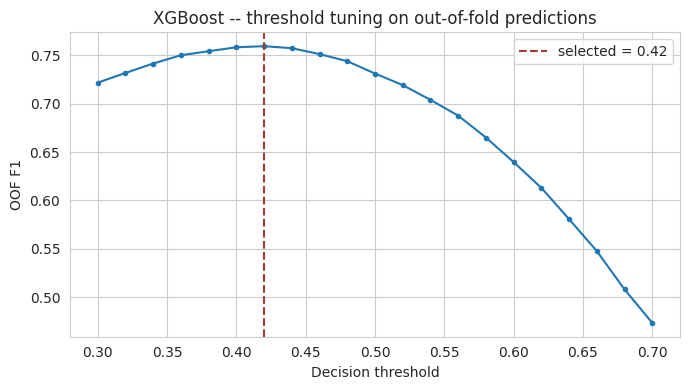

In [5]:
oof_proba = cross_val_predict(
    candidates[best_name], X_train_t, y_train, cv=cv, method='predict_proba', n_jobs=1
)[:, 1]

thresholds = np.arange(0.30, 0.71, 0.02)
f1s = [f1_score(y_train, (oof_proba >= t).astype(int)) for t in thresholds]
best_threshold = thresholds[np.argmax(f1s)]
best_oof_f1 = max(f1s)

print(f'Best threshold: {best_threshold:.2f}  (OOF F1 = {best_oof_f1:.4f})')
print(f'Default 0.50 threshold OOF F1: {f1_score(y_train, (oof_proba>=0.5).astype(int)):.4f}')

fig, ax = plt.subplots(figsize=(7,4))
ax.plot(thresholds, f1s, marker='o', markersize=3)
ax.axvline(best_threshold, color='#A23B32', linestyle='--', label=f'selected = {best_threshold:.2f}')
ax.set_xlabel('Decision threshold'); ax.set_ylabel('OOF F1')
ax.set_title(f'{best_name} -- threshold tuning on out-of-fold predictions')
ax.legend()
plt.tight_layout()
plt.savefig(OUT_DIR / 'threshold_tuning.png', dpi=110)
plt.show()


## 4. Refit the winner on the full training set, wrap with the tuned threshold

In [6]:
from sklearn.base import clone

base_model = clone(candidates[best_name])
base_model.fit(X_train_t, y_train)

final_model = ThresholdedClassifier(base_estimator=base_model, threshold=float(best_threshold))
final_model.fit(X_train_t, y_train)

print(f'Final model: {best_name}, threshold={best_threshold:.2f}')


Final model: XGBoost, threshold=0.42


## 5. Evaluate on test — the only time it's touched

In [7]:
y_pred_default = base_model.predict(X_test_t)             # sklearn's built-in 0.5 threshold
y_pred_tuned = final_model.predict(X_test_t)               # our tuned threshold
y_proba = final_model.predict_proba(X_test_t)[:, 1]

print('=== Default 0.5 threshold ===')
print(classification_report(y_test, y_pred_default, target_names=['No failure','Failure']))
print('=== Tuned threshold ===', f'({best_threshold:.2f})')
print(classification_report(y_test, y_pred_tuned, target_names=['No failure','Failure']))

test_auc = roc_auc_score(y_test, y_proba)
test_f1_default = f1_score(y_test, y_pred_default)
test_f1_tuned = f1_score(y_test, y_pred_tuned)
print(f'Test ROC-AUC: {test_auc:.4f}')
print(f'Test F1 -- default threshold: {test_f1_default:.4f}  |  tuned threshold: {test_f1_tuned:.4f}')


=== Default 0.5 threshold ===
              precision    recall  f1-score   support

  No failure       0.77      0.82      0.79      3661
     Failure       0.77      0.70      0.73      3072

    accuracy                           0.77      6733
   macro avg       0.77      0.76      0.76      6733
weighted avg       0.77      0.77      0.77      6733

=== Tuned threshold === (0.42)
              precision    recall  f1-score   support

  No failure       0.83      0.69      0.76      3661
     Failure       0.70      0.83      0.76      3072

    accuracy                           0.76      6733
   macro avg       0.76      0.76      0.76      6733
weighted avg       0.77      0.76      0.76      6733

Test ROC-AUC: 0.8572
Test F1 -- default threshold: 0.7319  |  tuned threshold: 0.7581


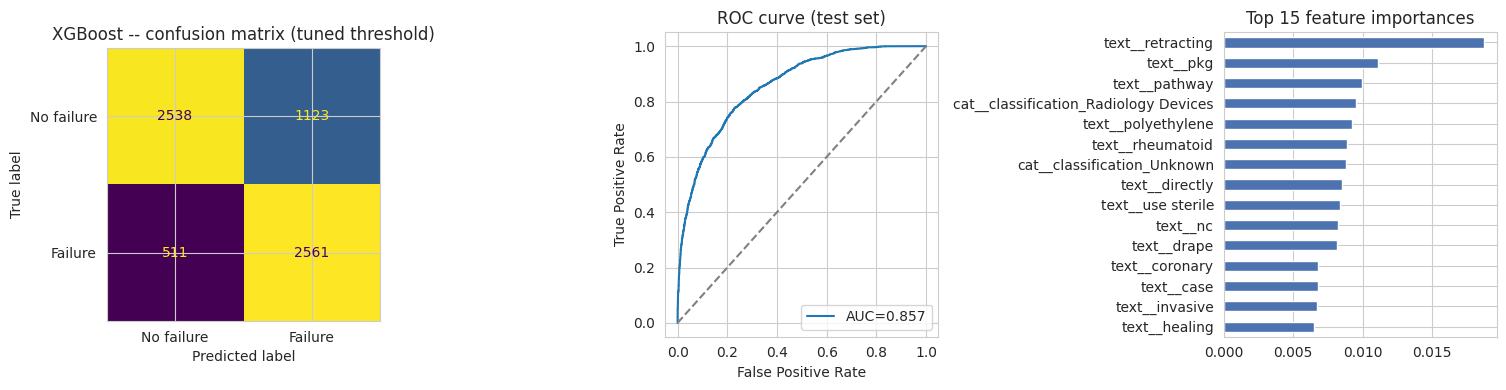

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15,4))

cm = confusion_matrix(y_test, y_pred_tuned)
ConfusionMatrixDisplay(cm, display_labels=['No failure','Failure']).plot(ax=axes[0], colorbar=False)
axes[0].set_title(f'{best_name} -- confusion matrix (tuned threshold)')

fpr, tpr, _ = roc_curve(y_test, y_proba)
axes[1].plot(fpr, tpr, label=f'AUC={test_auc:.3f}')
axes[1].plot([0,1],[0,1],'--',color='gray')
axes[1].set_xlabel('False Positive Rate'); axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC curve (test set)'); axes[1].legend()

feature_names = preprocessor.get_feature_names_out()
if hasattr(base_model, 'feature_importances_'):
    importances = pd.Series(base_model.feature_importances_, index=feature_names)
    importances.sort_values(ascending=False).head(15).sort_values().plot(kind='barh', ax=axes[2], color='#4C72B0')
    axes[2].set_title('Top 15 feature importances')

plt.tight_layout()
plt.savefig(OUT_DIR / 'test_evaluation.png', dpi=110)
plt.show()


## 6. Save artifacts

In [9]:
joblib.dump(preprocessor, OUT_DIR / 'pipeline.pkl')
joblib.dump(preprocessor, BACKEND_ML_DIR / 'pipeline.pkl')
joblib.dump(final_model, OUT_DIR / 'model.pkl')
joblib.dump(final_model, BACKEND_ML_DIR / 'model.pkl')

import shutil
shutil.copy('model_classes.py', BACKEND_ML_DIR / 'model_classes.py')

model_size_mb = (BACKEND_ML_DIR / 'model.pkl').stat().st_size / 1e6
print(f'Saved pipeline.pkl, model.pkl, model_classes.py to {BACKEND_ML_DIR}/')
print(f'model.pkl size: {model_size_mb:.2f} MB')


Saved pipeline.pkl, model.pkl, model_classes.py to backend_ml/
model.pkl size: 0.37 MB


In [10]:
metrics_payload = {
    'target': 'failure (binary)',
    'selected_model': best_name,
    'selection_method': '5-fold stratified CV on training set (ROC-AUC)',
    'cv_roc_auc': {name: {'mean': round(float(s.mean()),4), 'std': round(float(s.std()),4)} for name,s in cv_results.items()},
    'decision_threshold': round(float(best_threshold), 3),
    'threshold_tuning_method': 'max F1 on out-of-fold training predictions',
    'test_roc_auc': round(float(test_auc), 4),
    'test_f1_default_threshold': round(float(test_f1_default), 4),
    'test_f1_tuned_threshold': round(float(test_f1_tuned), 4),
    'test_precision_tuned': round(float(precision_score(y_test, y_pred_tuned)), 4),
    'test_recall_tuned': round(float(recall_score(y_test, y_pred_tuned)), 4),
    'model_size_mb': round(model_size_mb, 2),
}
with open(OUT_DIR / 'metrics.json', 'w') as f:
    json.dump(metrics_payload, f, indent=2)
print(json.dumps(metrics_payload, indent=2))


{
  "target": "failure (binary)",
  "selected_model": "XGBoost",
  "selection_method": "5-fold stratified CV on training set (ROC-AUC)",
  "cv_roc_auc": {
    "Logistic Regression": {
      "mean": 0.7936,
      "std": 0.0055
    },
    "Random Forest": {
      "mean": 0.8419,
      "std": 0.0083
    },
    "XGBoost": {
      "mean": 0.8551,
      "std": 0.007
    }
  },
  "decision_threshold": 0.42,
  "threshold_tuning_method": "max F1 on out-of-fold training predictions",
  "test_roc_auc": 0.8572,
  "test_f1_default_threshold": 0.7319,
  "test_f1_tuned_threshold": 0.7581,
  "test_precision_tuned": 0.6952,
  "test_recall_tuned": 0.8337,
  "model_size_mb": 0.37
}


## 7. Sanity check — load exactly as FastAPI would, in a fresh process

In [11]:
import subprocess, sys as _sys
verify = f'''
import sys
sys.path.insert(0, {str(BACKEND_ML_DIR)!r})
import joblib
from model_classes import ThresholdedClassifier
pipeline = joblib.load({str(BACKEND_ML_DIR / "pipeline.pkl")!r})
model = joblib.load({str(BACKEND_ML_DIR / "model.pkl")!r})
import pandas as pd
sample = pd.DataFrame([{{
    "classification": "Cardiovascular",
    "description": "implantable cardiac defibrillator lead insulation failure",
    "mfr_loo_event_count": 40, "mfr_countries_all": 5, "mfr_devices_all": 20, "description_len": 58,
    "classification_prior_count": 10, "event_year": 2018,
}}])
X = pipeline.transform(sample)
print("Predicted:", model.predict(X)[0], " P(failure)=", round(model.predict_proba(X)[0,1],3))
'''
result = subprocess.run([_sys.executable, '-c', verify], capture_output=True, text=True)
print(result.stdout)
if result.returncode != 0:
    print("VERIFICATION FAILED"); print(result.stderr)
else:
    print("VERIFICATION PASSED")


Predicted: 0  P(failure)= 0.358

VERIFICATION PASSED
